
# Simulación numérica de ecuaciones diferenciales estocásticas

**Complemento práctico a la Sección 2 (Cálculo estocástico).**

Basado en el artículo introductorio de Desmond J. Higham (2001), *"An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations"*, SIAM Review.

**Idea del notebook:** hasta ahora, en el trabajo, las SDEs (browniano, Itô, Ornstein-Uhlenbeck) se han tratado de forma analítica sin entrar en más detalle. El articulo de Higham introduce de forma bastante intuitiva cómo se prodían simular de forma numérica, sin necesidad de resolución analitica (que en ocasiones es ser dificil de encontrar o puede no tener forma analítica).

**Contenidos:**
1. Simulación de una trayectoria browniana
2. Integrales estocásticas: Itô vs. Stratonovich (tres ejemplos)
3. Ornstein-Uhlenbeck: Euler-Maruyama y Milstein

Este jupyter adapta los contenidos de Highan 2001 de acuerdo a los contenidos vistos en el máster y más especificamente en este TFM, junto con la adaptación en el lenguaje de programación de Matlab (original) a python.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(42)    # Reproducibilidad de los datos

# Estandarizacion del tamaño y estilo de las figuras
plt.rcParams['figure.figsize'] = (8, 4.5)  
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
})

## 1. Simulación de una trayectoria browniana

La definición del movimiento browniano de la Sección 2 implicaba: 
- $W_0=0$, incrementos independientes con probabilidad 1 
- $W_t-W_s\sim\mathcal N(0,t-s)$ distribución normal.
- Incrementos independientes $W(t_{i-1})-W(t_{i})$ para cualquier $0 \le t_1 < t_2 < \dots < t_n$, las variables aleatorias

Para simularlo, se discretiza el intervalo $[0,T]$ en $N$ pasos de tamaño $\delta t = T/N$, y se generan los incrementos $\delta W_j \sim \sqrt{\delta t}\,\mathcal N(0,1)$ de forma independiente. La trayectoria se construye mediante la acumulación de incrementos de la siguiente forma:
$$
W_j = W_{j-1} + \delta W_j.
$$


-----
Esta recursión no es un objeto nuevo: es la Definición 2.1 (paseo aleatorio escalado) y Observacion 2.2 escrita de otra forma. Allí:

$$
W^{(n)}(t)=\frac{1}{\sqrt n}\sum_{i=1}^{\lfloor nt\rfloor} X_i,
$$

con $X_i=\pm1$. Definiendo el incremento individual ya escalado como $\delta W_j:=X_j/\sqrt n$ (el paso crudo $X_i=\pm1$ dividido por $\sqrt n$, tal como se discutió al construir esa definición), la misma suma se reescribe de forma recursiva:

$$
W^{(n)}(t_j) = W^{(n)}(t_{j-1}) + \delta W_j.
$$

Es decir, se acumulan los incrementos uno a uno en vez de sumarlos todos de golpe con el símbolo $\sum$. La única diferencia con la simulación de este notebook es que aquí $\delta W_j\sim\sqrt{\delta t}\,\mathcal N(0,1)$ (gaussiano) en lugar de $\pm1/\sqrt n$ (moneda) — ambas formulas terminan por converger al mismo proceso por el teorema central del límite visto en la Observación 2.2.




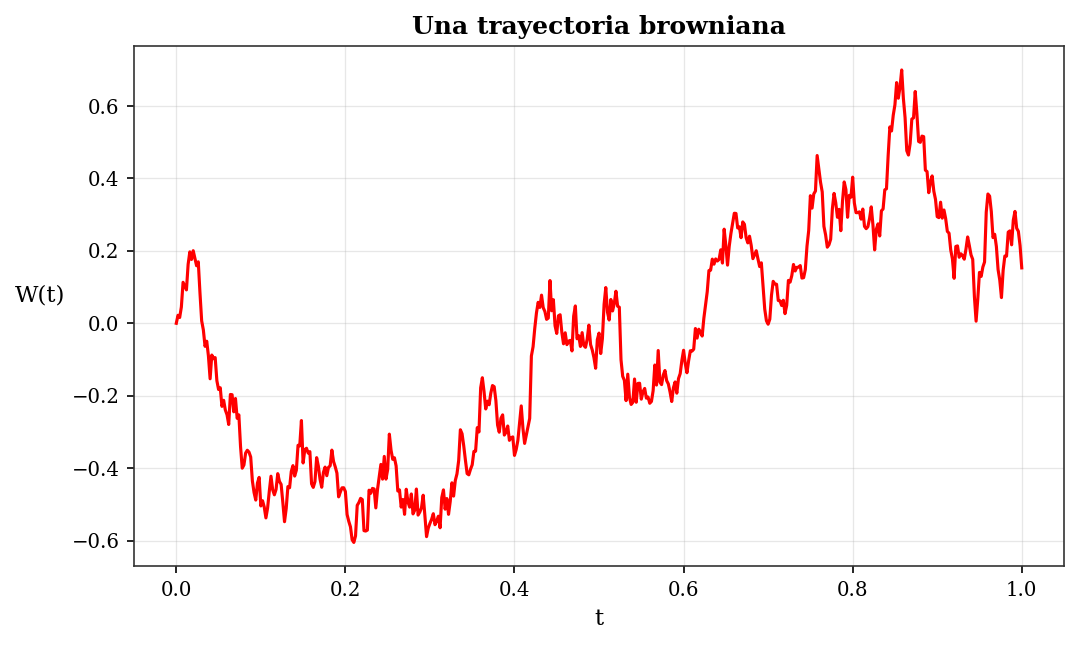

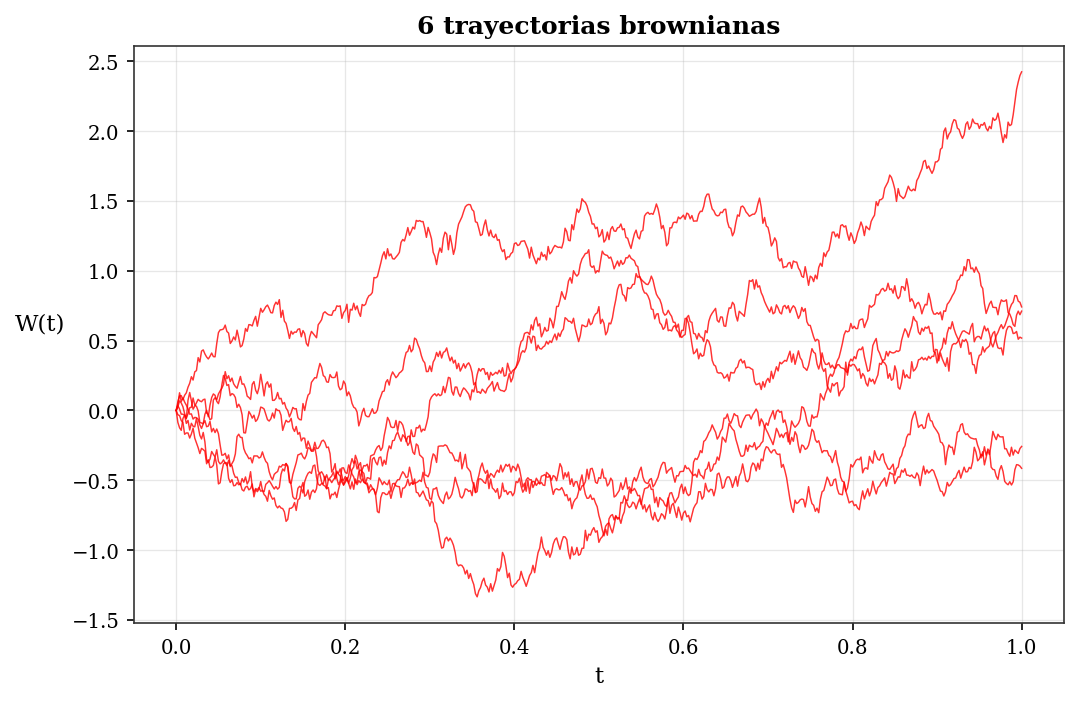

In [3]:
#Parametros de la simulacion- Discretizacion temporal
T = 1
N = 500
dt = T / N

#Simulacion de las trayectorias
dW = np.sqrt(dt) * np.random.randn(N)       # incrementos independientes
W = np.cumsum(dW)                           # trayectoria acumulada (W(0)=0 se añade al graficar)

t = np.linspace(0, T, N + 1)
plt.plot(t, np.concatenate(([0], W)), 'r-')
plt.xlabel('t')
plt.ylabel('W(t)', rotation=0, labelpad=15)
plt.title('Una trayectoria browniana')
plt.grid(alpha=0.3)

#####################################################
#####################################################
# Parametros de la simulacion- Discretizacion temporal
T = 1
N = 500
dt = T / N
M = 6  # numero de trayectorias

#### Simulacion de las trayectorias
dW_paths = np.sqrt(dt) * np.random.randn(M, N)
W_paths = np.cumsum(dW_paths, axis=1)  # una trayectoria por fila

# Añadimos la columna de ceros (W(0)=0) para cada trayectoria
W_paths_full = np.concatenate((np.zeros((M, 1)), W_paths), axis=1)  # forma (M, N+1)
t = np.linspace(0, T, N + 1)

plt.figure(figsize=(8, 5))
plt.plot(t, W_paths_full.T, 'r-', alpha=0.8, linewidth=0.7)  # .T para que cada columna sea una trayectoria
plt.xlabel('t')
plt.ylabel('W(t)', rotation=0, labelpad=15)
plt.title(f'{M} trayectorias brownianas')
plt.grid(alpha=0.3)


## 2. Integrales estocásticas: Itô vs. Stratonovich

En la Sección 2 (Definición 2.5) se definió la integral de Itô como el límite de las sumas $\sum_{i=0}^{n-1} g(t_i)\,\big(W_{t_{i+1}}-W_{t_i}\big)$ en el **extremo izquierdo** de cada subintervalo. Una reformulación de lo visto en el trabajo sería:
$$
\int_0^T g(s)\,dW_s \approx \sum_{j} g(t_j)\big(W(t_{j+1})-W(t_j)\big).
$$

Para comprobarlo numéricamente se calculan tres integrales, con integrandos $g$ de complejidad creciente, comparando siempre contra su valor exacto:

1. $g(t)=1$ — caso trivial, sirve para comprobar que la suma reproduce la propia definición del browniano.
2. $g(t)=W_t$ — el ejemplo del artículo de Higham. Aquí además se compara frente a la construcción alternativa de Stratonovich (evaluando en el **punto medio** de cada subintervalo en lugar del extremo izquierdo). Como curiosidad, sin entrar mucho en detalle: la diferencia entre ambas integrales no es un error numérico, sino una diferencia intrínseca a la estructura matemática de cada una.
3. $g(t)=t$ — integrando determinista, para comprobar que la definición también funciona cuando $g$ no depende del propio browniano.



### Integral: $g(t)=W_t$ (Itô vs. Stratonovich)


In [9]:
#Parametros de la simulacion- Discretizacion temporal
N = 500
dt = T / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)
W_left = np.concatenate(([0], W[:-1]))   # Calculamos extremo izquierdo de cada subinterv

# Itô para extremo izquierdo 
ito = np.sum(W_left * dW)

# Stratonovich para el punto medio 
Z = np.sqrt(dt / 4) * np.random.randn(N)   # requiere de ruido extra para el punto medio
strat = np.sum((0.5 * (W_left + W) + Z) * dW)

ito_exacto = 0.5 * (W[-1]**2 - T)
strat_exacto = 0.5 * W[-1]**2

print(f"Suma de Itô         :{ito:.2f}   (valor exacto: {ito_exacto:.2f})")
print(f"Suma de Stratonovich: {strat:.2f}   (valor exacto: {strat_exacto:.2f})")
print("\n")
print(f"Diferencia entre ambas integrales (~T/2 = {T/2}): {strat - ito:.2f}")


Suma de Itô         :-0.28   (valor exacto: -0.24)
Suma de Stratonovich: 0.24   (valor exacto: 0.26)


Diferencia entre ambas integrales (~T/2 = 0.5): 0.51



## 3. Ornstein-Uhlenbeck: Euler-Maruyama y Milstein

Estos metodos de simulacion son genericos: se aplican a **cualquier** SDE de la forma $dX_t=f(X_t)\,dt+g(X_t)\,dW_t$, sin importar la forma concreta de $f$ y $g$. Las aplicaremos a **Ornstein-Uhlenbeck** (Seccion 2.3):
$$
dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t,
$$
es decir, $f(X_t)=\theta(\mu-X_t)$ y $g(X_t)=\sigma$ (constante).

El método **Euler-Maruyama** discretiza el tiempo en pasos $\Delta t$ y avanza con
$$
X_j = X_{j-1} + f(X_{j-1})\,\Delta t + g(X_{j-1})\,\Delta W_j.
$$

El método **Milstein** añade un termino de correccion de mayor orden,
$$
X_j = X_{j-1} + \Delta t\, f(X_{j-1}) + g(X_{j-1})\,\Delta W_j + \frac12\, g(X_{j-1})\, g'(X_{j-1})\Big[(\Delta W_j)^2 - \Delta t\Big],
$$
pero al ser $g$ constante en OU, $g'=0$ y el termino de correccion se anula identicamente: **Milstein colapsa a Euler-Maruyama** en este caso. 

Como OU si tiene solucion cerrada (Seccion 2.3), se compara directamente la simulacion frente a la formula exacta:
$$
X_t = X_0e^{-\theta t} + \mu\big(1-e^{-\theta t}\big) + \sigma e^{-\theta t}\int_0^t e^{\theta s}\,dW_s.
$$


/tmp/ipykernel_3859/2598859906.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


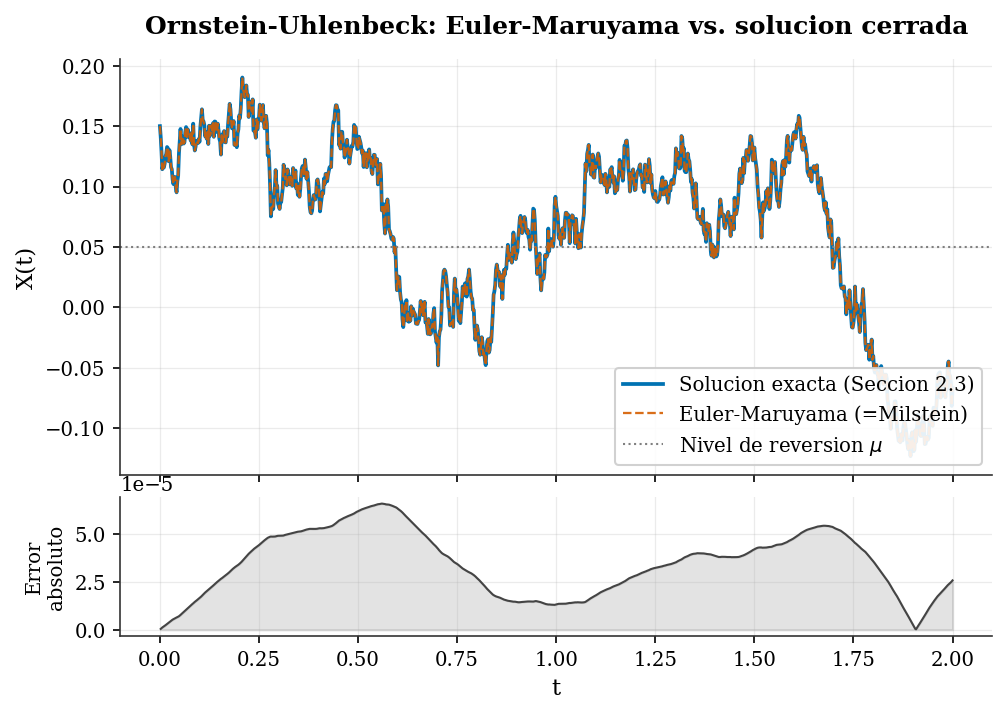

Error maximo entre EM y la solucion exacta: 0.00007
Valor final simulado: -0.0668   |   Nivel de reversion mu: 0.05


In [ ]:
#Parametros de la simulacion y discretizacion temporal
theta, mu_ou, sigma_ou, X0 = 1.5, 0.05, 0.2, 0.15   
T_ou = 2
N_ou = 1000
dt_ou = T_ou / N_ou

dW_ou = np.sqrt(dt_ou) * np.random.randn(N_ou)
t_grid_ou = np.linspace(dt_ou, T_ou, N_ou)


# Euler-Maruyama (identico a Milstein, ya que g es constante)
X_em = np.zeros(N_ou)
X_temp = X0
for j in range(N_ou):
    f = theta * (mu_ou - X_temp)
    g = sigma_ou
    X_temp = X_temp + dt_ou * f + g * dW_ou[j]
    X_em[j] = X_temp

# Solucion exacta, evaluando la integral estocastica con la MISMA trayectoria dW 
integral_acumulada = np.cumsum(np.exp(theta * t_grid_ou) * dW_ou)
X_exacta = X0 * np.exp(-theta * t_grid_ou) + mu_ou * (1 - np.exp(-theta * t_grid_ou)) \
           + sigma_ou * np.exp(-theta * t_grid_ou) * integral_acumulada

error = np.abs(X_em - X_exacta)


#####################################################
##################################################### Representaciones
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# Paths
ax1.plot(np.concatenate(([0], t_grid_ou)), np.concatenate(([X0], X_exacta)),
         color='#0072B2', linewidth=1.8, zorder=2, label='Solucion exacta (Seccion 2.3)')
ax1.plot(np.concatenate(([0], t_grid_ou)), np.concatenate(([X0], X_em)),
         color='#D55E00', linestyle='--', linewidth=1.1, alpha=0.9, zorder=3, label='Euler-Maruyama (=Milstein)')
ax1.axhline(mu_ou, color='gray', linestyle=':', linewidth=1, label=r'Nivel de reversion $\mu$')
ax1.set_ylabel('X(t)')
ax1.set_title('Ornstein-Uhlenbeck: Euler-Maruyama vs. solucion cerrada', pad=12)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.grid(alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Errores
ax2.plot(t_grid_ou, error, color='#444444', linewidth=1)
ax2.fill_between(t_grid_ou, 0, error, color='#444444', alpha=0.15)
ax2.set_xlabel('t')
ax2.set_ylabel('Error\nabsoluto', fontsize=9.5)
ax2.grid(alpha=0.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.tight_layout()
#fig.savefig('ou_EM_exacta.pdf', bbox_inches='tight')
plt.show()

print(f"Error maximo entre EM y la solucion exacta: {np.max(np.abs(X_em - X_exacta)):.5f}")
print(f"Valor final simulado: {X_em[-1]:.4f}   |   Nivel de reversion mu: {mu_ou}")


### Nota sobre diferencias finitas: esquemas explicitos vs. implicitos

El esquema de arriba es **explicito**: el drift y la difusion se evaluan en $X_{j-1}$. De hecho, salvo por el termino de ruido $g\,\Delta W_j$, Euler-Maruyama **es** literalmente el metodo de Euler explicito de EDOs aplicado al drift.

La contrapartida seria un **Euler-Maruyama implicito** (o *backward*), evaluando el drift en el punto desconocido $X_j$ en lugar de $X_{j-1}$:
$$
X_j = X_{j-1} + f(X_j)\,\Delta t + g(X_{j-1})\,\Delta W_j.
$$
En general esto obliga a resolver una ecuacion (no lineal, si $f$ lo es) en cada paso. Para OU, sin embargo, $f$ es lineal en $X_j$, asi que se puede despejar directamente sin necesidad de ningun solver:
$$
X_j(1+\theta\Delta t) = X_{j-1} + \theta\mu\Delta t + \sigma\Delta W_j \quad\Longrightarrow\quad X_j = \frac{X_{j-1}+\theta\mu\Delta t+\sigma\Delta W_j}{1+\theta\Delta t}.
$$

No se entra en un analisis de estabilidad mas riguroso (queda fuera del alcance de este TFM).

/tmp/ipykernel_3859/1812627522.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


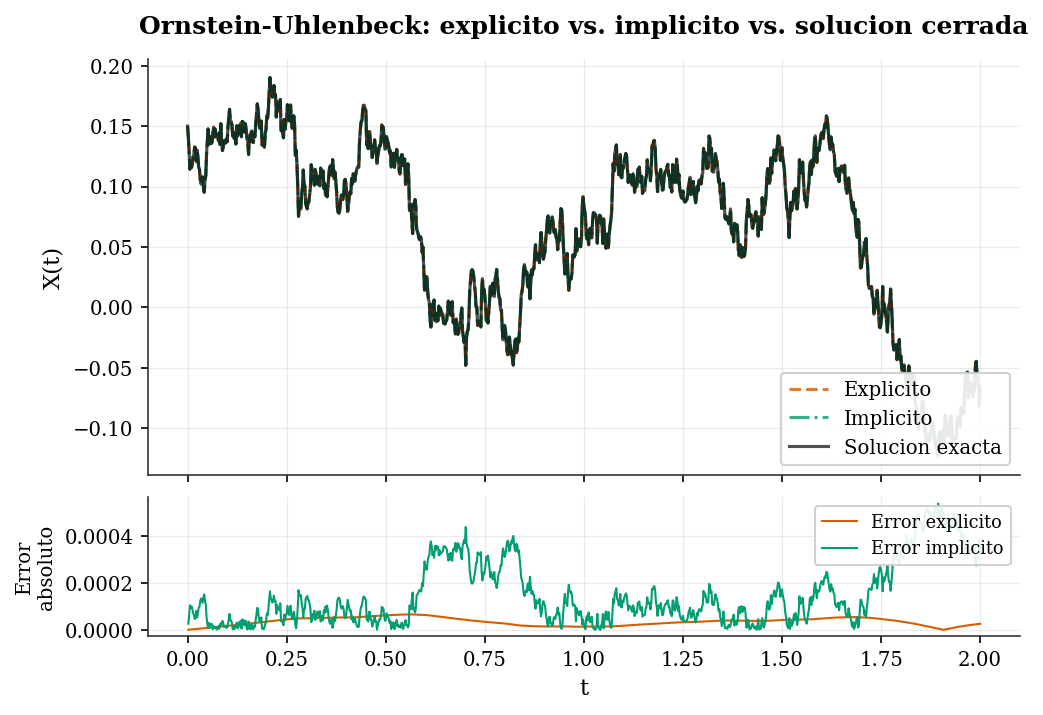

Error maximo (explicito): 0.00007
Error maximo (implicito): 0.00054


In [11]:
#  Euler-Maruyama implicito (mismo browniano que arriba, para comparar en igualdad de condiciones) ---
X_impl = np.zeros(N_ou)
X_temp = X0
for j in range(N_ou):
    X_temp = (X_temp + theta * mu_ou * dt_ou + sigma_ou * dW_ou[j]) / (1 + theta * dt_ou)
    X_impl[j] = X_temp

error_em = np.abs(X_em - X_exacta)
error_impl = np.abs(X_impl - X_exacta)

#####################################################
##################################################### Representaciones

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# Paths
ax1.plot(np.concatenate(([0], t_grid_ou)), np.concatenate(([X0], X_em)),
         color='#D55E00', linestyle='--', label='Explicito', alpha=0.8)
ax1.plot(np.concatenate(([0], t_grid_ou)), np.concatenate(([X0], X_impl)),
         color='#009E73', linestyle='-.', label='Implicito', alpha=0.8)
ax1.plot(np.concatenate(([0], t_grid_ou)), np.concatenate(([X0], X_exacta)),
         color="#050505", label='Solucion exacta', alpha=0.7)
ax1.set_ylabel('X(t)')
ax1.set_title('Ornstein-Uhlenbeck: explicito vs. implicito vs. solucion cerrada', pad=12)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.grid(alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Erroes
ax2.plot(t_grid_ou, error_em, color='#D55E00', linewidth=1, label='Error explicito')
ax2.plot(t_grid_ou, error_impl, color='#009E73', linewidth=1, label='Error implicito')
ax2.set_xlabel('t')
ax2.set_ylabel('Error\nabsoluto', fontsize=9.5)
ax2.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.tight_layout()
#fig.savefig('ou_explicito_implicito.pdf', bbox_inches='tight')
plt.show()

print(f"Error maximo (explicito): {np.max(error_em):.5f}")
print(f"Error maximo (implicito): {np.max(error_impl):.5f}")